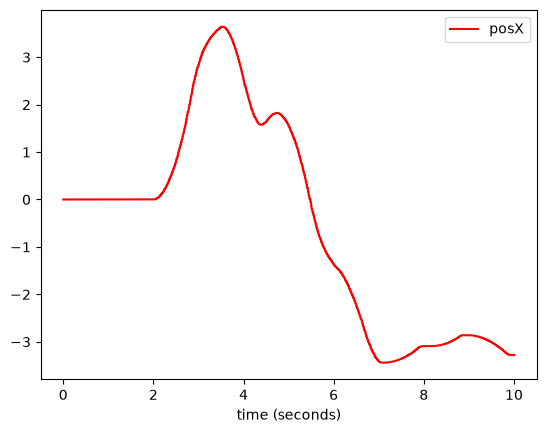

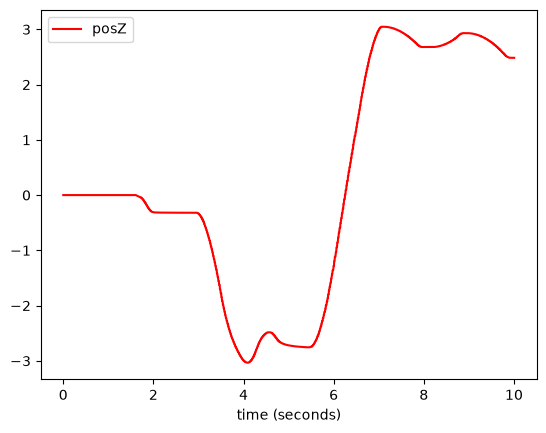

In [3]:
import sys
from lib.dds import *
from lib.time import *
from lib.dataplot import *

dpx = DataPlotter()
dpx.set_x("time (seconds)")
dpx.add_y("posX", "posX")

dpz = DataPlotter()
dpz.set_x("time (seconds)")
dpz.add_y("posZ", "posZ")

dds = DDS()
dds.start()

dds.subscribe(["posX", "posZ"])

t = Time()
t.start()

while t.get() < 10:
    posX = dds.wait("posX")
    posZ = dds.wait("posZ")

    delta_t = t.elapsed()

    dpx.append_x(t.get())
    dpx.append_y("posX", posX)

    dpz.append_x(t.get())
    dpz.append_y("posZ", posZ)


dpx.plot()
dpz.plot()

dds.stop()